# 4: Play around

Step 3.6 learned us that 
- Full model works the best, implement that here and let it predict.
- Using angle specific models does not help, so we don't use them here. 
Earlier phase learned that cropping helps! So we do taht here too. 

## 4.1 system setup

In [2]:
import sys
import os
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras import backend as K
import gc
import uuid
sys.path.append('../../utils')
import requests
import numpy as np
from ultralytics import YOLO
from  configloader import Configloader
import cnn_helpers
import implot
import file_io
import style
import car_detection as cd
import platform_dependency as plf

In [3]:
cnn_helpers.system_override()
device = cnn_helpers.system_pick_device()

System override applied - check if GPU is detected
Using CPU for deep learning.


In [4]:
config = Configloader()
yolo_path = os.path.join(config.get('directories','root_dir'), config.get('directories', 'yolo_path'))

In [5]:
CNN_SHAPE = 224
MODELDIR = os.path.join(
    config.get('directories', 'root_dir'), 
    config.get('directories', 'final_models_dirname'), 
    config.get('directories', 'brandphase'),
    )

CROP = True  #crop on bbox

In [6]:
detected_os = plf.get_platform()
if detected_os == 'Linux':
    print('A unix system was detected, please follow these steps to patch a known UNIX bug:')
    print('https://askubuntu.com/questions/1299255/how-can-i-solve-no-module-named-lzma')
    
detected_gpu = plf.get_gpu_info()
if detected_gpu == False:
    print(f'Notebook detected {detected_os} as OS and will use CPU for tasks where it can be done')
else:
    print(f'Notebook detected {detected_os} as OS and will use the available {detected_gpu} GPU')
    if detected_gpu != 'amd': 
        print(f"{detected_gpu} GPU's were not tested - code required workarounds to get working on AMD - no guarantees given.")


yolomodel = YOLO(yolo_path)  # YOLOv8 nano for speed, or 'yolov8s.pt' for more accuracy
if detected_gpu == 'amd': 
    yolomodel = plf.yolo_override(yolomodel)        

Notebook detected Windows as OS and will use CPU for tasks where it can be done


In [7]:
#We have established it's the best to use a CNN model trained on all angles at once: 
basedir = config.get('directories', 'root_dir')
fm = config.get('directories', 'final_models_dirname')
phase = 'brand'
best_approach = 'CNN_based_models'
full = 'full'
full_dir = os.path.join(basedir, fm, phase, best_approach,full)
if not os.path.exists(full_dir): 
    print('There are no trained models available on your machine. Download the models from: ')
    print('https://drive.google.com/file/d/1DBYWXS06_VDnx9qXGRDiibwN9lHJFlaP')
else: 
    ld = os.listdir(full_dir)
    kerasmodels = [x for x in ld if x.endswith('.keras')]
    labeldecoder = [x for x in ld if x.endswith('.json')]
    if len(kerasmodels) != len(labeldecoder) and len(kerasmodels) != 1:
        print('The correct folder structure was found, but the expected files are missing. Download the models from: ')
        print('https://drive.google.com/file/d/1DBYWXS06_VDnx9qXGRDiibwN9lHJFlaP')
    else: 
        print('FOUND MODEL: ', kerasmodels[0])
        print('FOUND LABELDECODER: ', labeldecoder[0])


FOUND MODEL:  trained model for -RESNET50- angles_mixed.keras
FOUND LABELDECODER:  trained model for -RESNET50- angles_mixed.json


In [8]:
dfr = None
def predict_something(image_urls): 
    tempdir = 'temp'
    os.makedirs(tempdir, exist_ok=True)
    yolomodel = YOLO(yolo_path)  # YOLOv8 nano for speed, or 'yolov8s.pt' for more accuracy
    if detected_gpu == 'amd': 
        yolomodel = plf.yolo_override(yolomodel)
    for image_url in image_urls: 
        assert image_url.endswith('.jpg')
        uuid_v4 = str(uuid.uuid4())

        save_path = os.path.join(tempdir, f"{uuid_v4}.jpg")
        spoof_headers = {
            "User-Agent": "Mozilla/5.0"
        }

        # Download and save
        response = requests.get(image_url, headers=spoof_headers)
        if response.status_code == 200:
            with open(save_path, "wb") as f:
                f.write(response.content)
        else:
            print(f"Download failed: {response.status_code}")
    data = []
    for file in os.listdir(tempdir):
        path = os.path.abspath(os.path.join(tempdir, file))
        details = cd.is_full_car(path, yolomodel)
        if details[0]: 
            xtop = int(details[2][0])
            ytop = int(details[2][1])
            xlow = int(details[2][2])
            ylow = int(details[2][3])
        else:
            xtop = -1
            ytop = -1
            xlow = -1
            ylow = -1
        data.append([path, xtop, ytop, xlow, ylow, 'fake_entry'])
        
    df = pd.DataFrame(data, columns= ['abs_path', 'yolobox_top_left_x', 'yolobox_top_left_y', 'yolobox_bottom_right_x', 'yolobox_bottom_right_y', 'brand'])


    p,a,decode = cnn_helpers.infer_cnn(full_dir, df, CROP, CNN_SHAPE)
    for row, dfr in zip(p, df.iterrows()): 
        i = np.argmax(row)
        img = mpimg.imread(dfr[1]['abs_path'])
        plt.imshow(img)
        plt.title(f"{decode[i]} ({row[i]})")
        K.clear_session()
        gc.collect()
        plt.show()
    file_io.wipe_folder(tempdir)

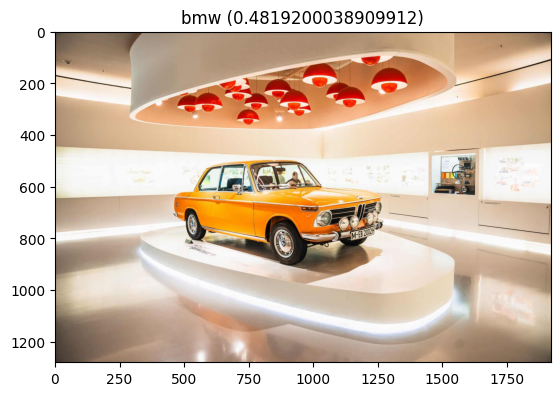

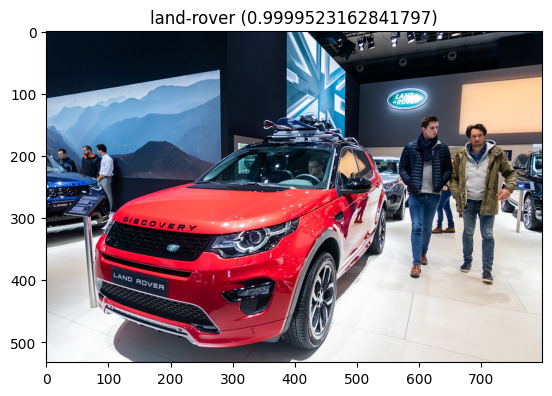

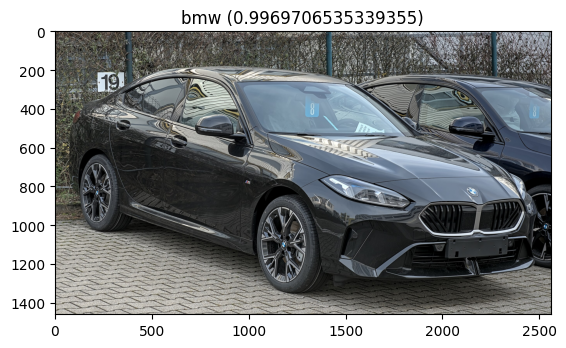

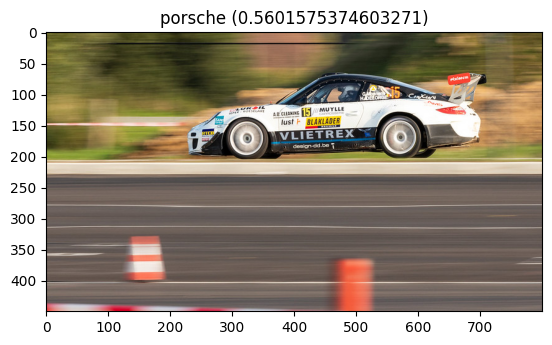

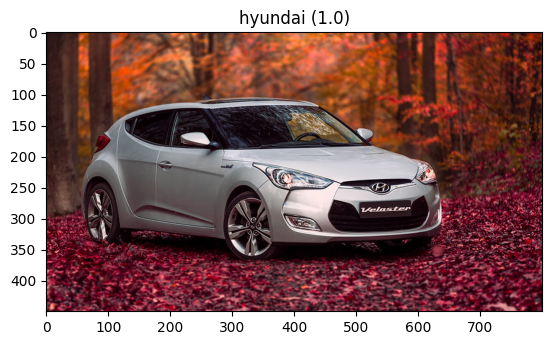

In [9]:
demo = [
    'https://live.staticflickr.com/7911/47234247942_87389399b9_c.jpg', 
    'https://live.staticflickr.com/1846/43543992205_8684355315_c.jpg', 
    'https://live.staticflickr.com/655335/50600295136_fb98b93983_c.jpg', 
    'https://upload.wikimedia.org/wikipedia/commons/thumb/f/ff/BMW_220d_%28F74%29_DSC_7359.jpg/2560px-BMW_220d_%28F74%29_DSC_7359.jpg',
    'https://cdn.bmwblog.com/wp-content/uploads/2024/08/bmw-museum-munich56.jpg'
    ]

predict_something(demo)

In [ ]:
#GPU and CPU works, confirmed CPC Unix/Windows